In [ ]:
%pip install probeinterface  
%pip install spikeinterface
%pip install pynwb
%pip install pynapple
%pip install mountainsort5
%pip install matplotlib
%pip install numpy==1.26.4
%pip install neuroconv

from readTrodesExtractedDataFile3 import readTrodesExtractedDataFile

import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import probeinterface as pi
import spikeinterface.full as si
import spikeinterface.preprocessing as spre
import pynapple as nap

from pathlib import Path
from datetime import timedelta
from scipy.ndimage import gaussian_filter
from probeinterface.plotting import plot_probe
from neuroconv.datainterfaces import PhySortingInterface
from datetime import datetime
from zoneinfo import ZoneInfo
from scipy.signal import butter, sosfiltfilt, decimate
from dateutil.tz import tzlocal
from pynwb import NWBFile, NWBHDF5IO
from pynwb.ecephys import LFP, ElectricalSeries
from pynwb.behavior import Position, SpatialSeries




python(39705) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Note: you may need to restart the kernel to use updated packages.


python(39706) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Note: you may need to restart the kernel to use updated packages.


python(39707) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


...

Note: you may need to restart the kernel to use updated packages.


python(39711) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Note: you may need to restart the kernel to use updated packages.


python(39712) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Note: you may need to restart the kernel to use updated packages.


In [2]:
dat_file_path = '/Users/minhphan/Rat1_HM_Neurons_20260305_112852_maze_merged.raw_group0.dat'
file_path_obj = Path(dat_file_path)
file_stem = file_path_obj.stem 

In [3]:
output_parent = file_path_obj.parent 
output_dir = output_parent / f"{file_stem}_sorting_output"
output_dir = str(output_dir)

if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created output folder: {output_dir}")
else:
    print(f"Output folder already exists: {output_dir}")


Output folder already exists: /Users/minhphan/Rat1_HM_Neurons_20260305_112852_maze_merged.raw_group0_sorting_output


# FIRST FUNCTION: 
    input: file path of the ephys .dat file,
    output: the phy output/folder

In [ ]:
def ephys_to_phy(dat_file_path, fs=30000.0, gain=0.195, offset=0.0, n_jobs=4):

    # [1/9] SET UP PATH
    file_path_obj = Path(dat_file_path)
    file_stem = file_path_obj.stem

    output_parent = file_path_obj.parent
    output_dir = output_parent / f"{file_stem}_sorting_output"
    output_dir.mkdir(exist_ok=True)

    print(f"\nProcessing {file_stem}")
    print(f"Output folder: {output_dir}")

    # [2/9] LOAD DATA
    raw = readTrodesExtractedDataFile(dat_file_path)
    full_traces_raw = raw['data']['voltage']

    # [3/9] QC TRACE PLOT
    start_time = 33.0
    window_duration = 5.0
    offset_spacing = 600

    start_frame = int(start_time * fs)
    end_frame = int((start_time + window_duration) * fs)

    traces_slice = full_traces_raw[start_frame:end_frame, :]
    traces_uV = traces_slice.astype(np.float32) * gain + offset

    num_samples = traces_uV.shape[0]
    time_vector = np.linspace(start_time,
                              start_time + (num_samples / fs),
                              num_samples)

    fig, axes = plt.subplots(32, 1, figsize=(10, 60), sharex=True)

    print("[3/9] Plotting traces...")

    for i, ax in enumerate(axes):
        start_ch = i * 4
        if start_ch >= traces_uV.shape[1]:
            break
        group_traces = traces_uV[:, start_ch:start_ch + 4]
        for local_idx in range(4):
            trace = group_traces[:, local_idx] + (local_idx * offset_spacing)
            ax.plot(time_vector, trace, color='black', linewidth=0.5)
        ax.invert_yaxis()

    plt.tight_layout()

    plot_path = output_dir / f"{file_stem}_traces.png"
    plt.savefig(plot_path, dpi=150)
    plt.close(fig)
    print(f"Trace plot saved: {plot_path}")

    # [4/9] CREATE RECORDING
    rec = si.NumpyRecording(
        traces_list=[full_traces_raw],
        sampling_frequency=fs
    )
    rec.set_channel_gains(gain)
    rec.set_channel_offsets(offset)

    # [5/9] PROBE GEOMETRY
    rows, cols = 8, 4
    inter_tetrode_spacing = 250.0
    diamond_offsets = np.array([[0, 10], [10, 0], [0, -10], [-10, 0]])

    all_positions = []
    all_device_indices = []
    group_ids = []
    tetrode_idx = 0

    for r in range(rows):
        for c in range(cols):
            x_center = c * inter_tetrode_spacing
            y_center = r * inter_tetrode_spacing
            for local_idx in range(4):
                pos = [
                    x_center + diamond_offsets[local_idx, 0],
                    y_center + diamond_offsets[local_idx, 1]
                ]
                all_positions.append(pos)
                all_device_indices.append(tetrode_idx * 4 + local_idx)
                group_ids.append(tetrode_idx)
            tetrode_idx += 1

    probe = pi.Probe(ndim=2, si_units='um')
    probe.set_contacts(
        positions=all_positions,
        shapes='circle',
        shape_params={'radius': 5}
    )
    probe.set_device_channel_indices(all_device_indices)

    rec = rec.set_probe(probe)
    rec.set_property("group", group_ids)
    print(f"[5/9] Probe attached. Groups: {len(np.unique(group_ids))}")

    # [6/9] PREPROCESSING
    print("[6/9] Preprocessing...")
    rec_filtered = spre.bandpass_filter(rec, 300, 6000)

    bad_channel_ids, _ = spre.detect_bad_channels(
        rec_filtered,
        n_neighbors=3,
        dead_channel_threshold=-0.3
    )
    print(f"Bad channels: {bad_channel_ids}")

    if len(bad_channel_ids) > 0:
        rec_interpolated = spre.interpolate_bad_channels(
            rec_filtered,
            bad_channel_ids=bad_channel_ids
        )
    else:
        rec_interpolated = rec_filtered

    rec_cmr = spre.common_reference(
        rec_interpolated,
        reference='global',
        operator='median'
    )
    rec_processed = spre.whiten(rec_cmr, dtype='float32')

    # [7/9] SAVE PROCESSED RECORDING
    print("[7/9] Saving processed recording...")
    processed_folder = output_dir / "processed_binary"
    if processed_folder.exists():
        shutil.rmtree(processed_folder)

    rec_saved = rec_processed.save(
        folder=processed_folder,
        format='binary',
        overwrite=True,
        n_jobs=1,
        chunk_duration="1s",
        progress_bar=True
    )

    # [8/9] SORTING
    sorter_name = 'mountainsort5'
    para = si.get_default_sorter_params(sorter_name)
    para['filter'] = False
    para['whiten'] = False

    sorter_folder = output_dir / "sorting_work_folder"
    if sorter_folder.exists():
        shutil.rmtree(sorter_folder)

    print(f"[8/9] Running sorter: {sorter_name}")

    sorting = si.run_sorter_by_property(
        sorter_name=sorter_name,
        recording=rec_saved,
        grouping_property='group',
        folder=sorter_folder,
        verbose=True,
        **para
    )

    final_folder = output_dir / "final_sorting_result"
    if final_folder.exists():
        shutil.rmtree(final_folder)

    sorting.save(folder=final_folder)
    print("Sorting complete")

    # [9/9] ANALYZER + PHY EXPORT
    print("[9/9] Building analyzer and exporting to Phy...")
    analyzer_folder = output_dir / "sorting_analyzer"
    if analyzer_folder.exists():
        shutil.rmtree(analyzer_folder)

    analyzer = si.create_sorting_analyzer(
        sorting=sorting,
        recording=rec_saved,
        format="binary_folder",
        folder=analyzer_folder,
        overwrite=True,
        sparse=True
    )

    job_kwargs = dict(n_jobs=n_jobs, chunk_duration="1s", progress_bar=True)

    analyzer.compute("random_spikes", max_spikes_per_unit=500, **job_kwargs)
    analyzer.compute("waveforms", ms_before=1.0, ms_after=2.0, **job_kwargs)
    analyzer.compute("templates", **job_kwargs)
    analyzer.compute("noise_levels", **job_kwargs)
    analyzer.compute("principal_components", n_components=3, mode="by_channel_local", **job_kwargs)
    analyzer.compute("quality_metrics", metric_names=["snr", "isi_violation", "firing_rate"], **job_kwargs)

    phy_folder = output_dir / "phy_export"
    if phy_folder.exists():
        shutil.rmtree(phy_folder)

    si.export_to_phy(
        sorting_analyzer=analyzer,
        output_folder=phy_folder,
        compute_pc_features=True,
        compute_amplitudes=True,
        remove_if_exists=True,
        copy_binary=False
    )

    # Save original dat path for phy_to_nwb LFP extraction
    with open(output_dir / "original_dat_path.txt", 'w') as f:
        f.write(dat_file_path)

    print("\nDone!")
    print(f"Open Phy with:\nphy template-gui {phy_folder}/params.py")


Processing Rat1_HM_Neurons_20260305_112852_maze_merged.raw_group0
Output folder: /Users/minhphan/Rat1_HM_Neurons_20260305_112852_maze_merged.raw_group0_sorting_output
Plotting traces...
Trace plot saved: /Users/minhphan/Rat1_HM_Neurons_20260305_112852_maze_merged.raw_group0_sorting_output/Rat1_HM_Neurons_20260305_112852_maze_merged.raw_group0_traces.png
Probe attached. Groups: 32
Preprocessing...
Detecting bad channels...
Bad channels: [ 28  30  44  51  56  59  70  94 106 108 126]


/opt/homebrew/Caskroom/miniconda/base/envs/neuro/lib/python3.11/site-packages/spikeinterface/core/base.py:967: UserWarning: The extractor is not serializable to file. The provenance will not be saved.
  warnings.warn("The extractor is not serializable to file. The provenance will not be saved.")
python(36762) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


write_binary_recording 
engine=process - n_jobs=1 - samples_per_chunk=30,000 - chunk_memory=14.65 MiB - total_memory=14.65 MiB - chunk_duration=1.00s


write_binary_recording (no parallelization): 100%|██████████| 751/751 [04:20<00:00,  2.89it/s]


Running sorter: mountainsort5


...

Using training recording of duration 300 sec with the sampling mode uniform
*** MS5 Elapsed time for SCHEME2 get_sampled_recording_for_training: 0.366 seconds ***
Running phase 1 sorting
Number of channels: 4
Number of timepoints: 9000000
Sampling frequency: 30000.0 Hz
Channel 0: [ 750. 1760.]
Channel 1: [ 760. 1750.]
Channel 2: [ 750. 1740.]
Channel 3: [ 740. 1750.]
Loading traces
*** MS5 Elapsed time for load_traces: 0.000 seconds ***
Detecting spikes

Adjacency for detect spikes with channel radius 200
[[0, 1, 2, 3], [0, 1, 2, 3], [0, 1, 2, 3], [0, 1, 2, 3]]

m = 0 (nbhd size: 4)
m = 1 (nbhd size: 4)
m = 2 (nbhd size: 4)
m = 3 (nbhd size: 4)
Detected 1411 spikes
*** MS5 Elapsed time for detect_spikes: 0.158 seconds ***
Removing duplicate times
*** MS5 Elapsed time for remove_duplicate_times: 0.000 seconds ***
Extracting 1411 snippets
*** MS5 Elapsed time for extract_snippets: 0.005 seconds ***
Computing PCA features with npca=12
*** MS5 Elapsed time for compute_pca_features: 0.116 s

/opt/homebrew/Caskroom/miniconda/base/envs/neuro/lib/python3.11/site-packages/spikeinterface/core/basesorting.py:380: UserWarning: The registered recording will not be persistent on disk, but only available in memory
  warnings.warn("The registered recording will not be persistent on disk, but only available in memory")


Sorting complete


estimate_sparsity (no parallelization): 100%|██████████| 751/751 [00:02<00:00, 262.31it/s]
/opt/homebrew/Caskroom/miniconda/base/envs/neuro/lib/python3.11/site-packages/spikeinterface/core/basesorting.py:380: UserWarning: The registered recording will not be persistent on disk, but only available in memory
  warnings.warn("The registered recording will not be persistent on disk, but only available in memory")
python(37160) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(37163) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(37164) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(37165) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
compute_waveforms (workers: 4 processes): 100%|██████████| 751/751 [00:21<00:00, 34.73it/s]
python(37168) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
pytho

Run:
phy template-gui  /Users/minhphan/Rat1_HM_Neurons_20260305_112852_maze_merged.raw_group0_sorting_output/phy_export/params.py

Done!
Open Phy with:
phy template-gui /Users/minhphan/Rat1_HM_Neurons_20260305_112852_maze_merged.raw_group0_sorting_output/phy_export/params.py


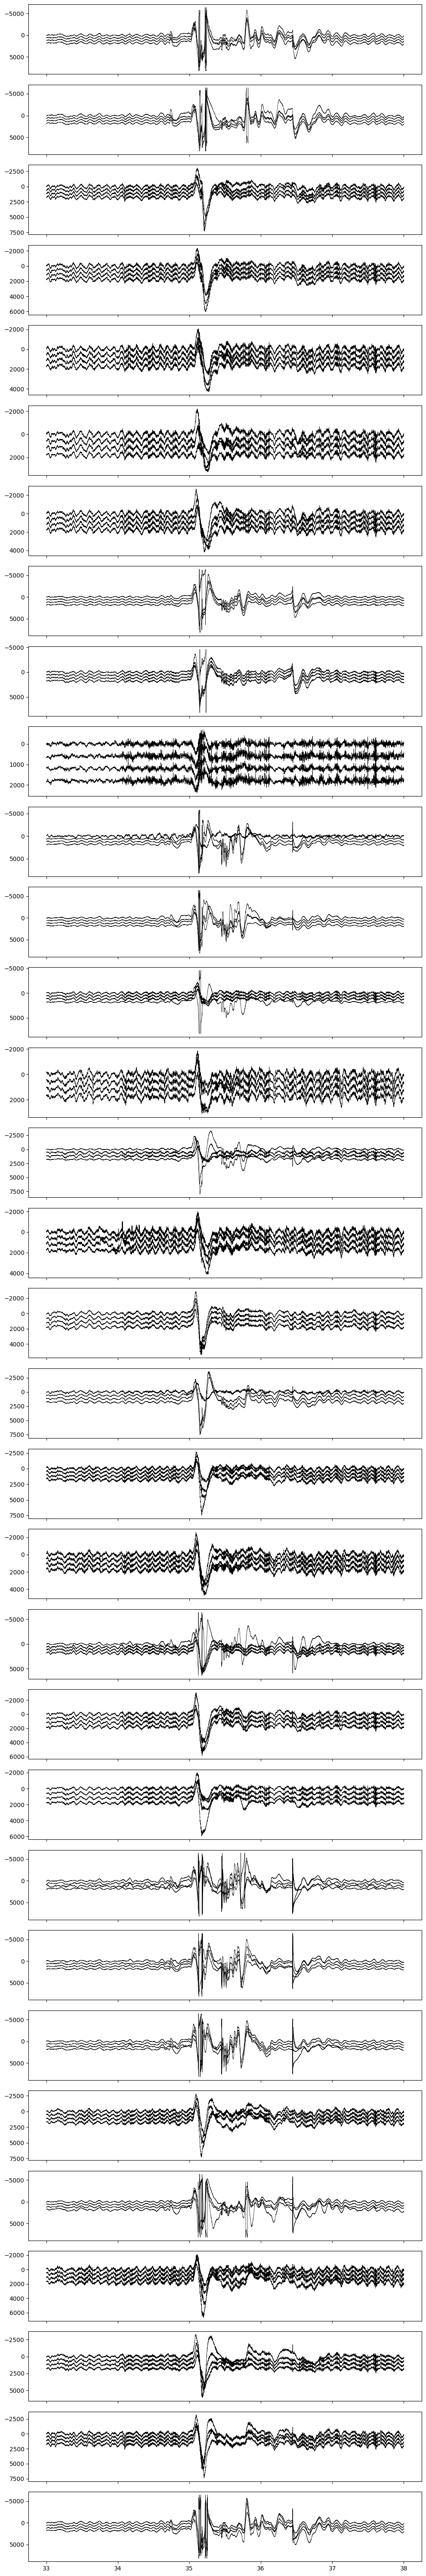

In [ ]:
ephys_to_phy(dat_file_path)

# FUNCTION 2
    Input: Phy folder from function 1
    Output: NWB file

In [59]:
file_path_obj = Path(dat_file_path)
file_stem = file_path_obj.stem

output_parent = file_path_obj.parent
output_dir = output_parent / f"{file_stem}_sorting_output"

phy_folder = output_dir / "phy_export"
phy_folder

PosixPath('/Users/minhphan/Rat1_HM_Neurons_20260305_112852_maze_merged.raw_group0_sorting_output/phy_export')

In [1]:
def phy_to_nwb(phy_folder):
    phy_folder = Path(phy_folder)
    nwb_output_path = str(phy_folder.parent / (phy_folder.stem + '.nwb'))

    # [1/2] CONVERT UNITS VIA NEUROCONV
    print("[1/2] Converting Phy units to NWB...")
    interface = PhySortingInterface(folder_path=str(phy_folder), verbose=False)
    metadata = interface.get_metadata()
    metadata["NWBFile"].update(session_start_time=datetime.now(ZoneInfo("US/Pacific")))
    interface.run_conversion(nwbfile_path=nwb_output_path, metadata=metadata, overwrite = True)

    # [2/2] APPEND DOWNSAMPLED LFP
    print("[2/2] Appending downsampled LFP...")
    params = {}
    with open(phy_folder / 'params.py', 'r') as f:
        exec(f.read(), params)
    sampling_frequency = float(params['sample_rate'])
    dat_path = params['dat_path']
    n_channels_dat = int(params['n_channels_dat'])
    dtype = params['dtype']

    raw_data = np.memmap(dat_path, dtype=dtype, mode='r')
    n_samples = raw_data.size // n_channels_dat
    raw_data = raw_data.reshape(n_samples, n_channels_dat)

    target_lfp_rate = 1250.0
    lfp_downsample_factor = int(sampling_frequency // target_lfp_rate)
    lfp_data = raw_data[::lfp_downsample_factor, :]
    lfp_sampling_frequency = sampling_frequency / lfp_downsample_factor

    with NWBHDF5IO(nwb_output_path, 'r+') as io:
        nwbfile = io.read()

        device = nwbfile.create_device(name='tetrode_array', description='8x4 tetrode diamond grid')
        electrode_group = nwbfile.create_electrode_group(
            name='tetrode_group',
            description='all tetrode channels',
            location='hippocampus',
            device=device
        )
        for ch in range(n_channels_dat):
            nwbfile.add_electrode(group=electrode_group, location='hippocampus')

        electrode_table_region = nwbfile.create_electrode_table_region(
            region=list(range(n_channels_dat)),
            description='all channels'
        )

        lfp_electrical_series = ElectricalSeries(
            name='LFP',
            data=lfp_data,
            electrodes=electrode_table_region,
            starting_time=0.0,
            rate=float(lfp_sampling_frequency),
            description=f'downsampled LFP at {lfp_sampling_frequency:.0f} Hz'
        )

        ecephys_module = nwbfile.create_processing_module(
            name='ecephys',
            description='processed electrophysiology data'
        )
        ecephys_module.add(LFP(electrical_series=lfp_electrical_series))

        io.write(nwbfile)

    print(f"LFP shape: {lfp_data.shape}, rate: {lfp_sampling_frequency} Hz")
    print(f"NWB file saved to: {nwb_output_path}")
    return nwb_output_path

In [76]:
phy_to_nwb(phy_folder=phy_folder)

[1/2] Converting Phy units to NWB...
[2/2] Appending downsampled LFP...
    LFP shape: (937645, 128), rate: 1250.0 Hz
NWB file saved to: /Users/minhphan/Rat1_HM_Neurons_20260305_112852_maze_merged.raw_group0_sorting_output/phy_export.nwb


'/Users/minhphan/Rat1_HM_Neurons_20260305_112852_maze_merged.raw_group0_sorting_output/phy_export.nwb'